In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models
import torch.optim as optim
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor


In [2]:
#setup directory
data_dir = "./tpc-imgs"

In [10]:
#prepocessing and augmentation
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize(256),                 
    transforms.CenterCrop(IMG_SIZE),       
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([transforms.RandomAffine(0, shear=10)], p=0.3),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.3)], p=0.3),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=(3, 5))], p=0.3),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [11]:
# Load full dataset once
full_dataset = datasets.ImageFolder(root=data_dir)

# Split indices
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

In [12]:
# setup DataLoaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=3)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=3)

device = "cuda" if torch.cuda.is_available() else "cpu"


In [13]:
#setup model resnet
modelR = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelR.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = modelR.fc.in_features
modelR.fc = nn.Linear(num_features, 2)

modelR.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelR.fc.parameters(), lr=1e-4)


In [13]:
%%time
epochs = 5

for epoch in range(epochs):
    modelR.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelR(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelR.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelR(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")


Epoch 1/5 - Loss: 0.7000
Validation Accuracy: 0.5876
Epoch 2/5 - Loss: 0.6444
Validation Accuracy: 0.6374
Epoch 3/5 - Loss: 0.6151
Validation Accuracy: 0.6590
Epoch 4/5 - Loss: 0.5957
Validation Accuracy: 0.6755
Epoch 5/5 - Loss: 0.5819
Validation Accuracy: 0.6886
CPU times: total: 2h 42min 49s
Wall time: 26min 8s


In [14]:
#setup model efficientnet
modelE = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelE.parameters():
    param.requires_grad = False

# Replace classifier
num_features = modelE.classifier[1].in_features
modelE.classifier[1] = nn.Linear(num_features, 2)

modelE.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE.classifier[1].parameters(), lr=1e-4)

In [21]:
%%time
for epoch in range(10):
    modelE.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelE(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelE.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelE(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")


Epoch 1/5 - Loss: 0.6663
Validation Accuracy: 0.6484
Epoch 2/5 - Loss: 0.6240
Validation Accuracy: 0.6690
Epoch 3/5 - Loss: 0.6019
Validation Accuracy: 0.6936
Epoch 4/5 - Loss: 0.5850
Validation Accuracy: 0.6911
Epoch 5/5 - Loss: 0.5749
Validation Accuracy: 0.7102
CPU times: total: 2h 7min 47s
Wall time: 21min 58s


In [40]:
%%time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, precision_score, recall_score, fbeta_score

# MODEL SETUP
modelE = models.efficientnet_b0(weights="IMAGENET1K_V1")
num_features = modelE.classifier[1].in_features
modelE.classifier[1] = nn.Linear(num_features, len(full_dataset.classes))

modelE = modelE.to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(device), label_smoothing=0.1)

#METRICS
def compute_metrics(model, dataloader, device, toxic_class=1):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, pos_label=toxic_class)
    recall = recall_score(all_labels, all_preds, pos_label=toxic_class)
    f2 = fbeta_score(all_labels, all_preds, beta=2, pos_label=toxic_class)

    return cm, precision, recall, f2

# TRAINING & VALIDATION LOOPS
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


# PHASE 1 — TRAIN CLASSIFIER HEAD
for param in modelE.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(modelE.classifier[1].parameters(), lr=2e-4)

def warmup(epoch):
    return min(1.0, (epoch + 1) / 3)

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

print("=== Phase 1: Training classifier head ===")
for epoch in range(6):
    train_loss, train_acc = train_one_epoch(modelE, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE, val_loader, criterion, device)

    if epoch < 3:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE, val_loader, device)

    print(f"\nEpoch {epoch+1}/6 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F2 Score:  {f2:.4f}")


# PHASE 2 — UNFREEZE TOP 30%
for name, param in modelE.named_parameters():
    if "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, modelE.parameters()), lr=3e-5)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e+1)/2))
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=2, eta_min=1e-6)

print("\n=== Phase 2: Unfreezing top layers ===")
for epoch in range(4):
    train_loss, train_acc = train_one_epoch(modelE, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE, val_loader, criterion, device)

    if epoch < 2:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE, val_loader, device)

    print(f"\nEpoch {epoch+1}/4 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F2 Score:  {f2:.4f}")


# PHASE 3 — FULL FINE-TUNE
for param in modelE.parameters():
    param.requires_grad = True

optimizer = optim.Adam(modelE.parameters(), lr=1e-5)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=5e-6)

print("\n=== Phase 3: Full fine-tuning ===")
for epoch in range(10):
    train_loss, train_acc = train_one_epoch(modelE, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE, val_loader, criterion, device)

    cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE, val_loader, device)

    print(f"\nEpoch {epoch+1}/10 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F2 Score:  {f2:.4f}")


=== Phase 1: Training classifier head ===

Epoch 1/6 | Train Acc: 0.5210 | Val Acc: 0.5374
Confusion Matrix:
 [[135 881]
 [ 40 935]]
Precision: 0.5149
Recall:    0.9590
F2 Score:  0.8179

Epoch 2/6 | Train Acc: 0.5575 | Val Acc: 0.6072
Confusion Matrix:
 [[288 728]
 [ 54 921]]
Precision: 0.5585
Recall:    0.9446
F2 Score:  0.8299

Epoch 3/6 | Train Acc: 0.6150 | Val Acc: 0.6419
Confusion Matrix:
 [[367 649]
 [ 64 911]]
Precision: 0.5840
Recall:    0.9344
F2 Score:  0.8342

Epoch 4/6 | Train Acc: 0.6512 | Val Acc: 0.6866
Confusion Matrix:
 [[480 536]
 [ 88 887]]
Precision: 0.6233
Recall:    0.9097
F2 Score:  0.8332

Epoch 5/6 | Train Acc: 0.6649 | Val Acc: 0.6871
Confusion Matrix:
 [[477 539]
 [ 84 891]]
Precision: 0.6231
Recall:    0.9138
F2 Score:  0.8358

Epoch 6/6 | Train Acc: 0.6713 | Val Acc: 0.6720
Confusion Matrix:
 [[436 580]
 [ 73 902]]
Precision: 0.6086
Recall:    0.9251
F2 Score:  0.8380

=== Phase 2: Unfreezing top layers ===

Epoch 1/4 | Train Acc: 0.6784 | Val Acc: 0.6816

In [43]:
torch.save(modelE.state_dict(), "model_final.pth")
print("Saved model to model_final.pth")

Saved model to model_final.pth


In [44]:
%%time
# MODEL CALIBRATION (TEMPERATURE SCALING)
class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


def calibrate_temperature(model, dataloader, device):
    model.eval()
    nll_criterion = nn.CrossEntropyLoss()

    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    temp_model = ModelWithTemperature(model).to(device)
    optimizer = optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

    def eval_closure():
        optimizer.zero_grad()
        loss = nll_criterion(logits / temp_model.temperature, labels)
        loss.backward()
        return loss

    optimizer.step(eval_closure)
    return temp_model

print("\n=== Calibrating model with temperature scaling ===")
modelE = calibrate_temperature(modelE, val_loader, device)
print("Learned temperature:", modelE.temperature.item())


# THRESHOLD TUNING (ON CALIBRATED MODEL)
def tune_threshold(model, dataloader, device, toxic_class=1):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, toxic_class]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = torch.tensor(all_probs).numpy()
    all_labels = torch.tensor(all_labels).numpy()

    best_t, best_f2, best_recall = 0.5, -1.0, -1.0
    for t in [i / 100 for i in range(10, 91, 2)]:  # 0.10 to 0.90 step 0.02
        preds = (all_probs >= t).astype(int)
        recall = recall_score(all_labels, preds, pos_label=toxic_class)
        f2 = fbeta_score(all_labels, preds, beta=2, pos_label=toxic_class)
        if f2 > best_f2:
            best_f2, best_t, best_recall = f2, t, recall

    return best_t, best_f2, best_recall

best_t, best_f2, best_recall = tune_threshold(modelE, val_loader, device)
print(f"\n=== Threshold tuning (calibrated model) ===")
print(f"Best threshold: {best_t:.2f}")
print(f"Best F2:        {best_f2:.4f}")
print(f"Recall at best: {best_recall:.4f}")




=== Calibrating model with temperature scaling ===
Learned temperature: 0.9682520031929016

=== Threshold tuning (calibrated model) ===
Best threshold: 0.28
Best F2:        0.8929
Recall at best: 0.9846
CPU times: total: 8min 57s
Wall time: 1min 44s


In [45]:
with open("temperature.txt", "w") as f:
    f.write(str(modelE.temperature.item()))
print("Saved temperature to temperature.txt")


Saved temperature to temperature.txt


In [46]:
%%time
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1. MODEL DEFINITION (with temperature)
# ============================================================

class ModelWithTemperature(nn.Module):
    def __init__(self, model, temperature):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.tensor([temperature]))

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


# ============================================================
# 2. LOAD TRAINED MODEL + APPLY CALIBRATION
# ============================================================

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier head (must match training)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)   # toxic vs clean

# Load your trained weights
model.load_state_dict(torch.load("model_final.pth", map_location=device))

# Wrap with temperature scaling
temperature = 1.1588963
model = ModelWithTemperature(model, temperature).to(device)
model.eval()


# ============================================================
# 3. PREPROCESSING PIPELINE (same as validation transforms)
# ============================================================

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])


# ============================================================
# 4. INFERENCE FUNCTION (with threshold = 0.34)
# ============================================================

THRESHOLD = 0.40   # tuned threshold

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    toxic_prob = probs[1].item()
    prediction = 1 if toxic_prob >= THRESHOLD else 0

    return {
        "prediction": "TOXIC" if prediction == 1 else "CLEAN",
        "toxic_probability": toxic_prob,
        "threshold_used": THRESHOLD
    }


# ============================================================
# 5. EXAMPLE USAGE
# ============================================================

result = predict_image("tpc-imgs\\nontoxic_images\\000\\000.jpg")
print(result)


{'prediction': 'TOXIC', 'toxic_probability': 0.9826502203941345, 'threshold_used': 0.4}
CPU times: total: 906 ms
Wall time: 378 ms


In [47]:
result = predict_image("tpc-imgs\\nontoxic_images\\003\\001.jpg")
print(result)


{'prediction': 'TOXIC', 'toxic_probability': 1.0, 'threshold_used': 0.4}


In [48]:
%%time
THRESHOLD = 0.40  # tuned threshold

def predict_folder(folder_path, save_toxic=False):
    results = []
    toxic_dir = os.path.join(folder_path, "toxic_detected")

    if save_toxic and not os.path.exists(toxic_dir):
        os.makedirs(toxic_dir)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            continue

        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]

        toxic_prob = probs[1].item()
        prediction = 1 if toxic_prob >= THRESHOLD else 0
        label = "TOXIC" if prediction == 1 else "CLEAN"

        # Save toxic images if requested
        if save_toxic and prediction == 1:
            img.save(os.path.join(toxic_dir, filename))

        results.append({
            "filename": filename,
            "prediction": label,
            "toxic_probability": toxic_prob,
            "threshold": THRESHOLD
        })

    return pd.DataFrame(results)


# ============================================================
# 5. RUN BATCH INFERENCE
# ============================================================

folder = "tpc-imgs\\nontoxic_images\\000"   # <-- change this to your folder
df = predict_folder(folder, save_toxic=True)

df.to_csv("batch_predictions.csv", index=False)
print("Saved results to batch_predictions.csv")
print(df.head())

Saved results to batch_predictions.csv
  filename prediction  toxic_probability  threshold
0  000.jpg      TOXIC           0.982650        0.4
1  001.jpg      TOXIC           0.844560        0.4
2  002.jpg      CLEAN           0.243147        0.4
3  003.jpg      TOXIC           0.819381        0.4
4  004.jpg      TOXIC           0.479852        0.4
CPU times: total: 5min 3s
Wall time: 55.4 s


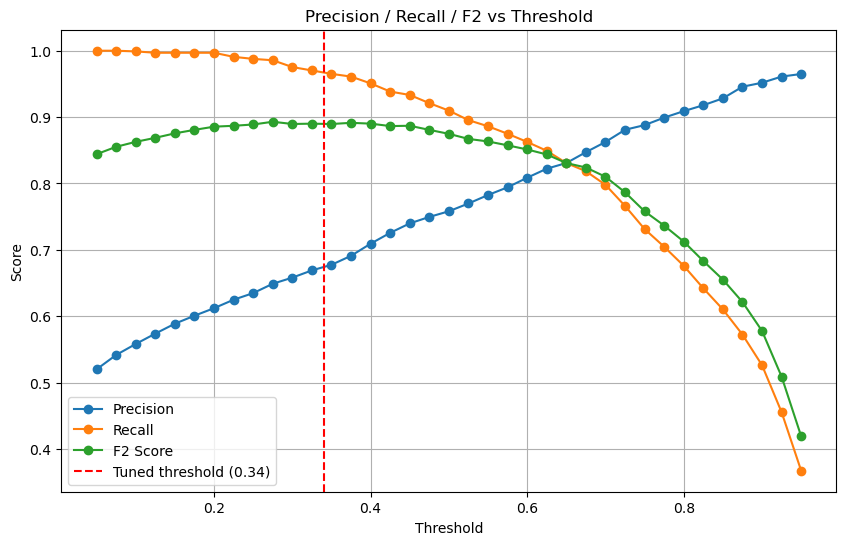

Best F2 threshold: 0.27 | F2=0.8930

Balanced thresholds (precision ≥ 0.70 and recall ≥ 0.90):
Threshold 0.40 | Precision=0.709 | Recall=0.951
Threshold 0.42 | Precision=0.726 | Recall=0.938
Threshold 0.45 | Precision=0.740 | Recall=0.933
Threshold 0.47 | Precision=0.750 | Recall=0.921
Threshold 0.50 | Precision=0.758 | Recall=0.910
CPU times: total: 4min 58s
Wall time: 58.5 s


In [49]:
%%time
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, fbeta_score

def evaluate_thresholds(model, dataloader, device, toxic_class=1):
    model.eval()
    all_probs, all_labels = [], []

    # Collect probabilities and labels
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, toxic_class]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    thresholds = np.linspace(0.05, 0.95, 37)
    precisions, recalls, f2_scores = [], [], []

    for t in thresholds:
        preds = (all_probs >= t).astype(int)
        precisions.append(precision_score(all_labels, preds, zero_division=0))
        recalls.append(recall_score(all_labels, preds))
        f2_scores.append(fbeta_score(all_labels, preds, beta=2))

    return thresholds, precisions, recalls, f2_scores


# === RUN EVALUATION ===
thresholds, precisions, recalls, f2_scores = evaluate_thresholds(modelE, val_loader, device)

# === PLOT ===
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions, label="Precision", marker="o")
plt.plot(thresholds, recalls, label="Recall", marker="o")
plt.plot(thresholds, f2_scores, label="F2 Score", marker="o")

plt.axvline(0.34, color="red", linestyle="--", label="Tuned threshold (0.34)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F2 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# === PRINT BEST BALANCED THRESHOLDS ===
best_f2_idx = np.argmax(f2_scores)
print(f"Best F2 threshold: {thresholds[best_f2_idx]:.2f} | F2={f2_scores[best_f2_idx]:.4f}")

# Find threshold where precision >= 0.70 AND recall >= 0.90
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precisions, recalls)
    if p >= 0.70 and r >= 0.90
]

if candidates:
    print("\nBalanced thresholds (precision ≥ 0.70 and recall ≥ 0.90):")
    for t, p, r in candidates:
        print(f"Threshold {t:.2f} | Precision={p:.3f} | Recall={r:.3f}")
else:
    print("\nNo threshold meets precision ≥ 0.70 and recall ≥ 0.90 simultaneously.")
